In [1]:
# Importing libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Loading preprocessed dataset, model and scaler

In [4]:
df = pd.read_csv(r"C:\Users\J.Shiva\OneDrive\Attachments\credit-risk-prediction\data\processed\loan_payments_preprocessed.csv")
xgb_model = joblib.load(r"C:\Users\J.Shiva\OneDrive\Attachments\credit-risk-prediction\models\xgb_model.pkl")
scaler = joblib.load(r"C:\Users\J.Shiva\OneDrive\Attachments\credit-risk-prediction\models\scaler.pkl")

print("Dataset shape:", df.shape)
print("Model loaded:", xgb_model)
print("Scaler loaded:", scaler)

Dataset shape: (54231, 22)
Model loaded: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, ...)
Scaler loaded: StandardScaler()


In [5]:
# Recreating train test split and scaling

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['target'])
y = df['target']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

print("Test shape:", X_test.shape)
print("Val shape:", X_val.shape)

Test shape: (8135, 21)
Val shape: (8113, 21)


In [7]:
# Finding optimal threshold using precision recall curve

In [8]:
y_val_proba = xgb_model.predict_proba(X_val_scaled)[:,1]

precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print("Optimal Threshold:", round(optimal_threshold, 4))
print("Best F1 Score:", round(f1_scores[optimal_idx], 4))
print("Precision at optimal:", round(precisions[optimal_idx], 4))
print("Recall at optimal:", round(recalls[optimal_idx], 4))

Optimal Threshold: 0.3048
Best F1 Score: 0.9168
Precision at optimal: 0.9699
Recall at optimal: 0.8691


In [9]:
# Plotting precision recall curve with optimal threshold

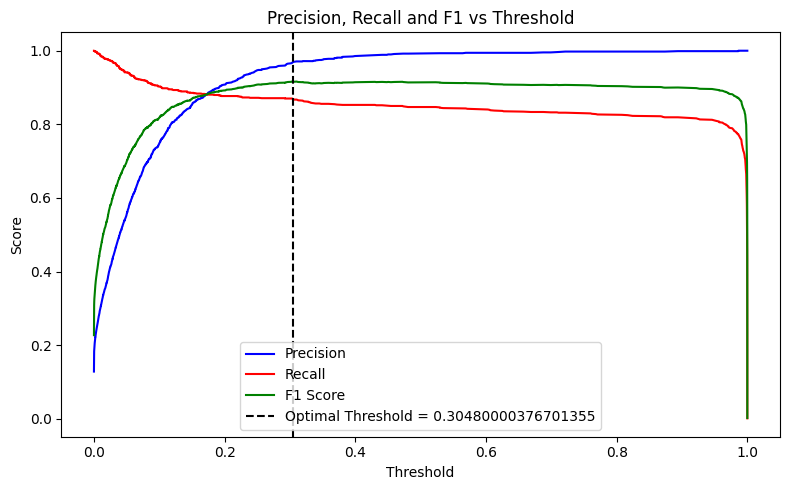

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='blue')
plt.plot(thresholds, recalls[:-1], label='Recall', color='red')
plt.plot(thresholds, f1_scores[:-1], label='F1 Score', color='green')
plt.axvline(x=optimal_threshold, color='black', linestyle='--', label=f'Optimal Threshold = {round(optimal_threshold, 4)}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall and F1 vs Threshold')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Evaluating model with optimal threshold on validation set

In [12]:
y_val_pred_tuned = (y_val_proba >= optimal_threshold).astype(int)

print("Validation Results with Optimal Threshold (0.3048):")
print(classification_report(y_val, y_val_pred_tuned))
print("ROC-AUC:", round(roc_auc_score(y_val, y_val_proba), 4))

Validation Results with Optimal Threshold (0.3048):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      7074
           1       0.97      0.87      0.92      1039

    accuracy                           0.98      8113
   macro avg       0.98      0.93      0.95      8113
weighted avg       0.98      0.98      0.98      8113

ROC-AUC: 0.982


In [13]:
# Final evaluation on test set

In [14]:
y_test_proba = xgb_model.predict_proba(X_test_scaled)[:,1]
y_test_pred_tuned = (y_test_proba >= optimal_threshold).astype(int)

print("Final Test Set Results with Optimal Threshold (0.3048):")
print(classification_report(y_test, y_test_pred_tuned))
print("ROC-AUC:", round(roc_auc_score(y_test, y_test_proba), 4))

Final Test Set Results with Optimal Threshold (0.3048):
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      7094
           1       0.95      0.85      0.90      1041

    accuracy                           0.98      8135
   macro avg       0.96      0.92      0.94      8135
weighted avg       0.98      0.98      0.97      8135

ROC-AUC: 0.9799


In [15]:
# Plotting confusion matrix on test set

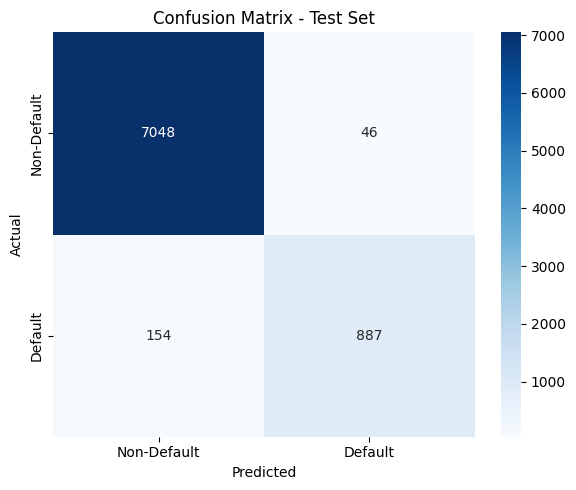

In [16]:
cm = confusion_matrix(y_test, y_test_pred_tuned)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Default', 'Default'],
            yticklabels=['Non-Default', 'Default'])
plt.title('Confusion Matrix - Test Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Confusion Matrix Interpretation
|  | Predicted Non-Default | Predicted Default |
|---|---|---|
| **Actual Non-Default** | 7048 (True Negative) | 46 (False Positive) |
| **Actual Default** | 154 (False Negative) | 887 (True Positive) |

- **7048** — Correctly identified non-defaulters
- **887** — Correctly caught defaulters ✅
- **154** — Missed defaulters (False Negatives) — costliest mistake in credit risk
- **46** — Good customers wrongly flagged as defaulters (False Positives)

**Business Insight:** Model catches 887 out of 1041 actual defaulters — missing only 154.
In real banking, each missed defaulter costs significantly more than a rejected good customer.

In [17]:
# Plotting feature importance

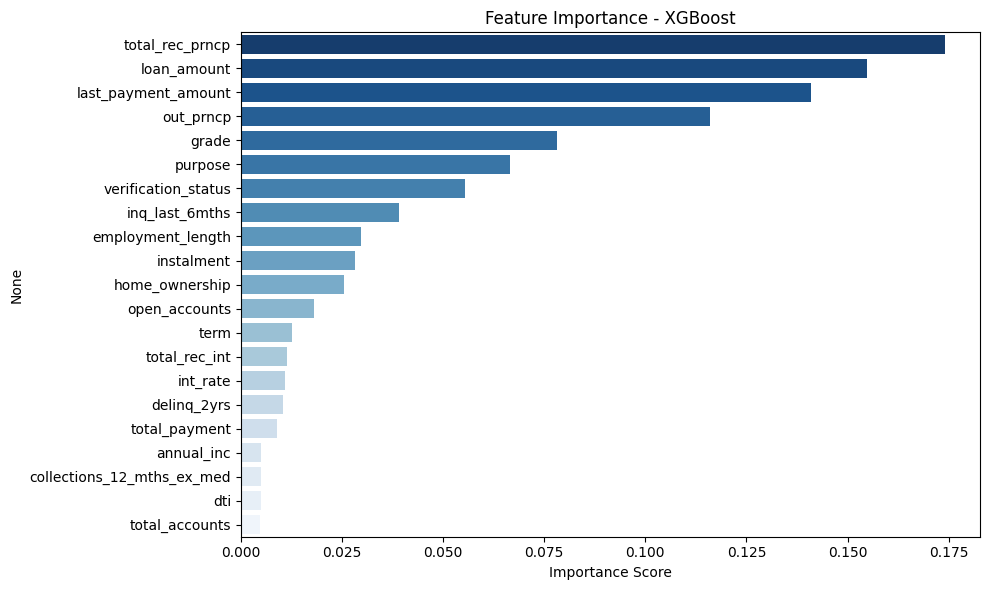

In [18]:
feat_imp = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='Blues_r')
plt.title('Feature Importance - XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Feature Importance Observations
- **total_rec_prncp** — most important feature, total principal received signals repayment behavior
- **loan_amount** — higher loan amounts increase default risk
- **last_payment_amount** — recent payment behavior strongly predicts future default
- **out_prncp** — outstanding principal, higher outstanding = higher risk
- **grade** — loan grade assigned by lender is a strong risk indicator
- **purpose** — reason for loan matters, small business and education riskier
- **verification_status** — whether income was verified impacts default probability
- **int_rate, dti, annual_inc** — low importance surprisingly, grade already captures interest rate info

In [19]:
# Plotting ROC curve

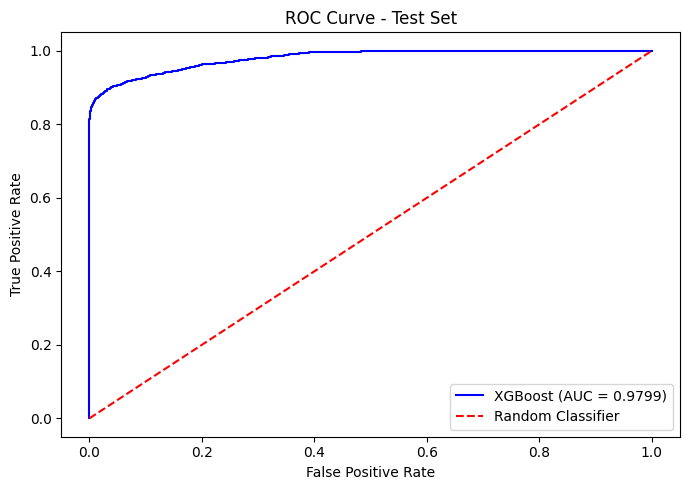

In [20]:
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
auc_score = round(roc_auc_score(y_test, y_test_proba), 4)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', label=f'XGBoost (AUC = {auc_score})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Test Set')
plt.legend()
plt.tight_layout()
plt.show()

## Notebook 4 Summary — Final Evaluation Complete

### Model Performance on Test Set
| Metric | Value |
|---|---|
| Accuracy | 98% |
| Recall (Default) | 0.85 |
| Precision (Default) | 0.95 |
| F1 Score (Default) | 0.90 |
| ROC-AUC | 0.9799 |
| Optimal Threshold | 0.3048 |

### Business Conclusion
- Model correctly identifies 887 out of 1041 actual defaulters
- Only 154 defaulters missed out of 8135 test samples
- Lowering threshold from 0.5 to 0.3048 improved recall without hurting precision
- Top risk signals — total principal received, loan amount, last payment amount, grade
- Model is production-ready for credit risk screening at a lending institution